#

In [6]:
#importing libraries
import pandas as pd
import ast
import seaborn as sns
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas() # converting data into pandas 

# data clean up
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])# converting datatype from object to date time

# safely converts a string representation of a Python object into an actual Python object
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)


In [11]:
df_US=df[df['job_country']=='United States']

In [12]:
df_US.shape

(206292, 17)

In [13]:
df['job_country'].value_counts()

job_country
United States               206292
India                        51088
United Kingdom               40375
France                       39922
Germany                      27694
                             ...  
Northern Mariana Islands         4
Lesotho                          3
Mauritania                       3
Bhutan                           3
Maldives                         2
Name: count, Length: 160, dtype: int64

In [14]:
df_skills=df_US.explode('job_skills')
df_skills[['job_title','job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,NaN
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,NaN
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [15]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count

job_skills  job_title_short          
airflow     Business Analyst               38
            Cloud Engineer                 27
            Data Analyst                  387
            Data Engineer                4716
            Data Scientist               1166
                                         ... 
zoom        Machine Learning Engineer       5
            Senior Data Analyst            50
            Senior Data Engineer           30
            Senior Data Scientist          25
            Software Engineer              16
Length: 1870, dtype: int64

In [20]:
type(df_skills_count)

pandas.Series

In [21]:
#Convert it to a DataFrame 

df_skills_count = (
    df_skills
    .groupby(['job_skills', 'job_title_short'])
    .size()
    .reset_index(name='skill_count')
)

df_skills_count.sort_values(
    by='skill_count',
    ascending=False,
    inplace=True
)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [22]:
job_titles=df_skills_count['job_title_short'].unique().tolist()
job_titles=sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

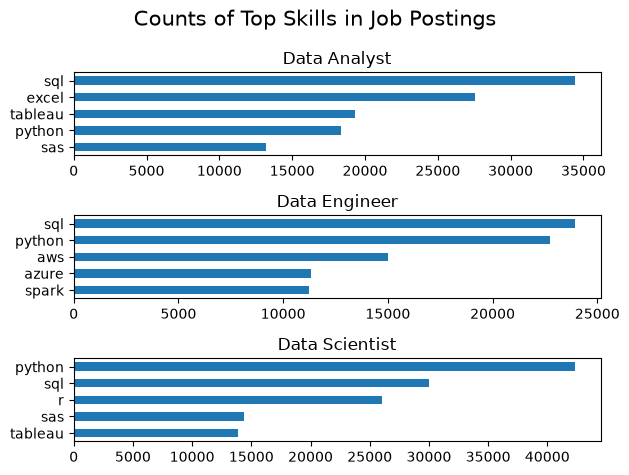

In [24]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)

    df_plot.plot(
        kind='barh',
        x='job_skills',
        y='skill_count',
        ax=ax[i],
        title=job_title
    )

    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
plt.tight_layout()
plt.show()

In [28]:
df_job_title_count=df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [29]:
df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [30]:
df_skills_perc = df_skills_count.merge(
    df_job_title_count,
    how='left',
    on='job_title_short'
)
df_skills_perc['skill_percent']=100*df_skills_perc['skill_count']/df_skills_perc['jobs_total']
df_skills_perc


,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


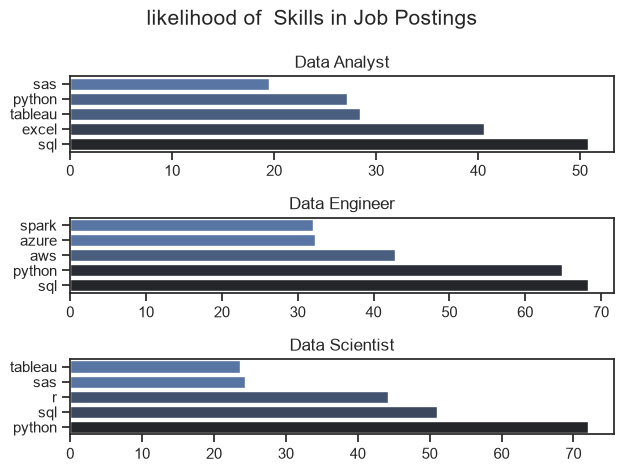

In [34]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)

    # df_plot.plot(
    #     kind='barh',
    #     x='job_skills',
    #     y='skill_percent',
    #     ax=ax[i],
    #     title=job_title
    # )
    # we are going to use sns
    sns.set_theme(style='ticks')
    sns.barplot(data=df_plot,x='skill_percent',y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].legend().set_visible(False)

fig.suptitle('likelihood of  Skills in Job Postings', fontsize=15)
plt.tight_layout()
plt.show()

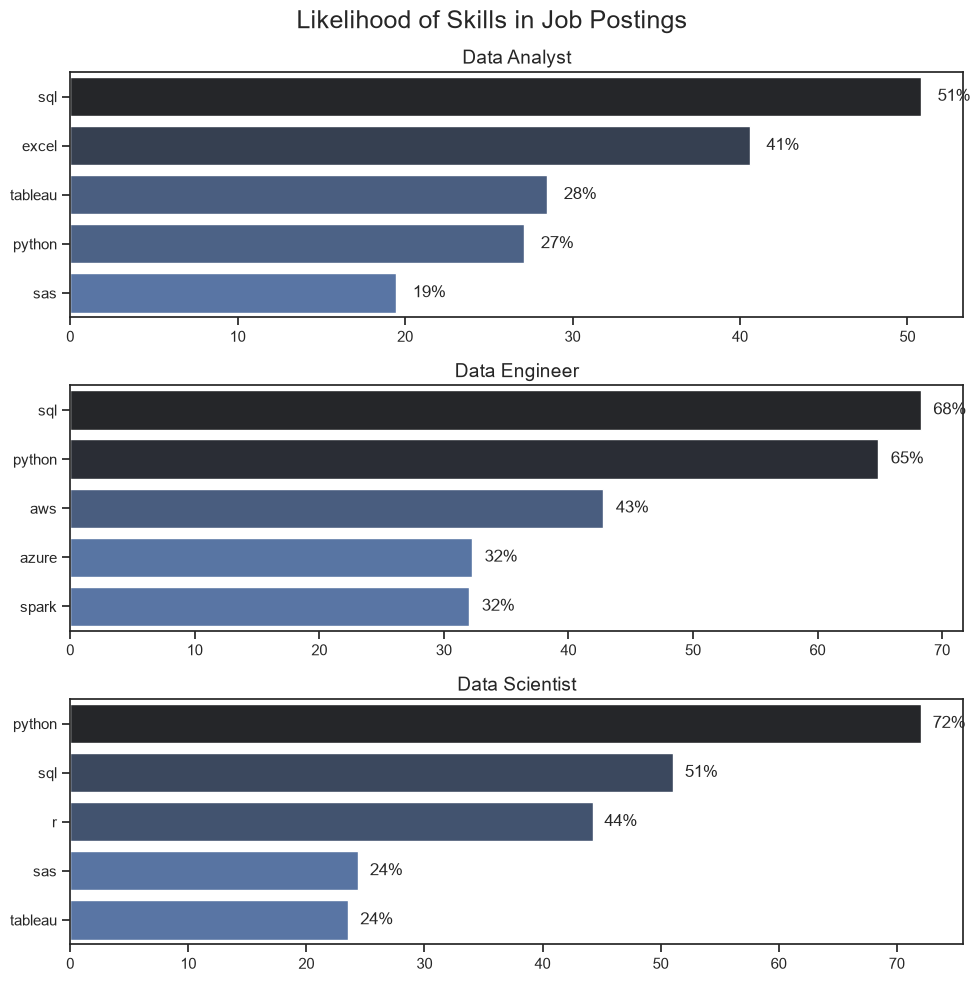

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 10))

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):

    # Top 5 skills in descending order
    df_plot = (
        df_skills_perc[df_skills_perc['job_title_short'] == job_title]
        .sort_values(by='skill_percent', ascending=False)
        .head(5)
    )

    sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        hue='skill_count',
        palette='dark:b_r',
        legend=False,
        ax=ax[i]
    )

    ax[i].set_title(job_title, fontsize=14)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

    # Add percentage labels
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')
    

fig.suptitle('Likelihood of Skills in Job Postings', fontsize=18)

plt.tight_layout()
plt.show()